In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a sample dataset

In [ ]:
data = {
    "date": [
        "2024-09-01",
        "2024-09-01",
        "2024-09-02",
        "2024-09-02",
        "2024-09-03",
        "2024-09-03",
        "2024-09-04",
        "2024-09-04",
        "2024-09-05",
        "2024-09-05",
        "2024-09-06",
        "2024-09-06",
        "2024-09-07",
        "2024-09-07",
        "2024-09-08",
        "2024-09-08",
        "2024-09-09",
        "2024-09-09",
        "2024-09-10",
        "2024-09-10",
    ],
    "category": [
        "Electronics",
        "Clothing",
        "Books",
        "Electronics",
        "Furniture",
        "Clothing",
        "Books",
        "Electronics",
        "Furniture",
        "Clothing",
        "Books",
        "Electronics",
        "Furniture",
        "Clothing",
        "Books",
        "Electronics",
        "Furniture",
        "Clothing",
        "Books",
        "Electronics",
    ],
    "units_sold": [
        15,
        30,
        20,
        10,
        5,
        25,
        18,
        8,
        12,
        22,
        25,
        7,
        6,
        28,
        15,
        11,
        7,
        18,
        20,
        12,
    ],
    "revenue_usd": [
        1500,
        750,
        300,
        1200,
        500,
        625,
        270,
        960,
        1200,
        550,
        375,
        840,
        600,
        700,
        225,
        1320,
        700,
        450,
        300,
        1440,
    ],
    "traffic_source": [
        "Direct",
        "Organic Search",
        "Social Media",
        "Direct",
        "Google Ads",
        "Direct",
        "Organic Search",
        "Social Media",
        "Google Ads",
        "Social Media",
        "Organic Search",
        "Direct",
        "Google Ads",
        "Social Media",
        "Organic Search",
        "Direct",
        "Google Ads",
        "Social Media",
        "Direct",
        "Organic Search",
    ],
}

# Створення DataFrame

In [ ]:
df = pd.DataFrame(data)

# Створи стовпчастий графік, що показує середній дохід для кожної категорії товарів:
Встанови порядок категорій за спаданням середнього доходу.
Продажі якої категорії у середньому найбільші?
Яка категорія продається менше всіх?

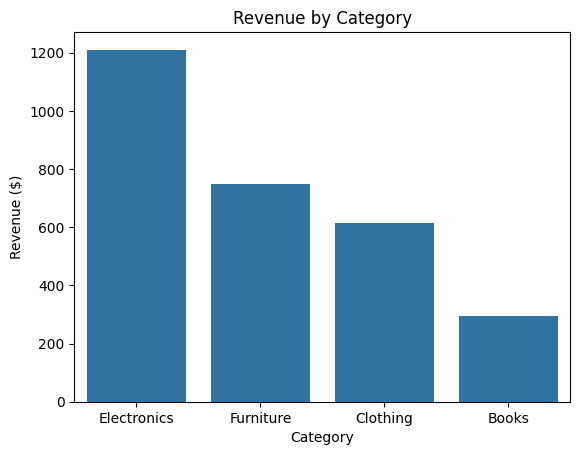

In [ ]:
order = df.groupby("category")["revenue_usd"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="category", y="revenue_usd", errorbar=("ci", False), order=order)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.show()

- Продажі якої категорії у середньому найбільші? Electronics
- Яка категорія продається менше всіх? Books

# Додай на попередній графік джерело трафіку як колір (hue). Зроби висновки щодо популярності джерел трафіку.

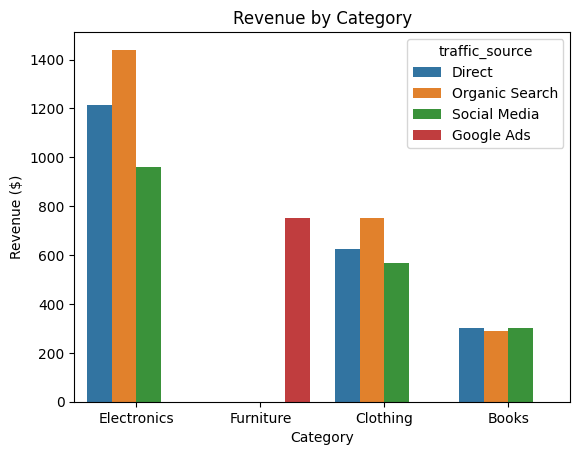

In [ ]:
order = df.groupby("category")["revenue_usd"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="category", y="revenue_usd", hue="traffic_source", errorbar=("ci", False), order=order)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.show()

### Зроби висновки щодо популярності джерел трафіку.
- Самий популярний - Organic Search
- У Furniture лише Google Ads
- З Google Ads більше нікуде не йде трафік
- Для Books трафік йде днаково з трьох основних каналів.

# Побудуй діаграму розсіювання для візуалізації зв'язку між кількістю товару у замовленні та доходом:

Встанови розмір маркерів у 100 одиниць для більшої наочності. Для цього додай параметр s=100.
Що можна сказати про характер взаємозв'язку між кількістю товару у замовленні та доходом?

/tmp/ipykernel_1979/1065942153.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


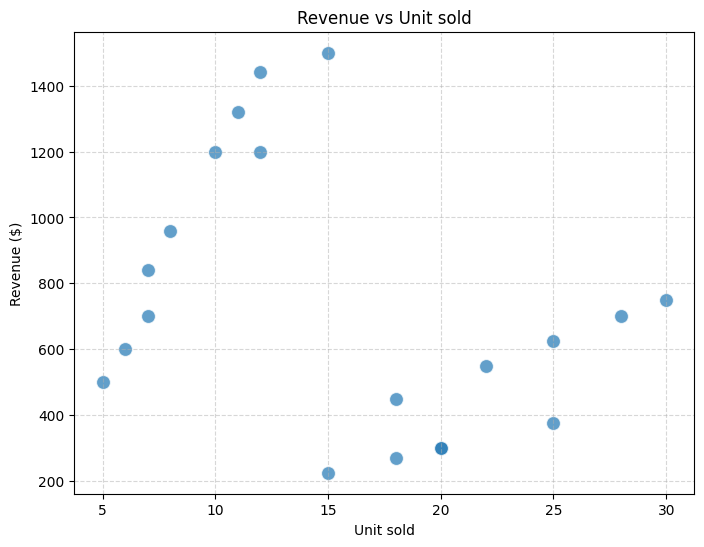

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="units_sold",
    y="revenue_usd",
    s=100,
    palette="viridis",
    alpha=0.7
)

plt.title("Revenue vs Unit sold")
plt.xlabel("Unit sold")
plt.ylabel("Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Що можна сказати про характер взаємозв'язку між кількістю товару у замовленні та доходом?
- До 15 одиниць: дохід зростає разом із кількістю — класична позитивна кореляція.
- 15 одиниць: спостерігається спад доходу, хоча кількість проданих одиниць збільшується. Це може свідчити про те, що товари з нижчою маржинальністю продаються більшими партіями.
- 15 - 30 одиниць: дохід зростає разом із кількістю — класична позитивна кореляція.(для товарів з нижчою маржинальністю)

Для бізнес‑аналізу варто розділити дані за категоріями товарів або ціновими сегментами, щоб зрозуміти, чому при середніх обсягах замовлень дохід падає.

# Додай категорію товару як колір на попередній графік:
Обери палітру "deep" для цього.
Чи є відмінності між категоріями на цьому графіку? Як би ти їх охарактеризував(-ла)?

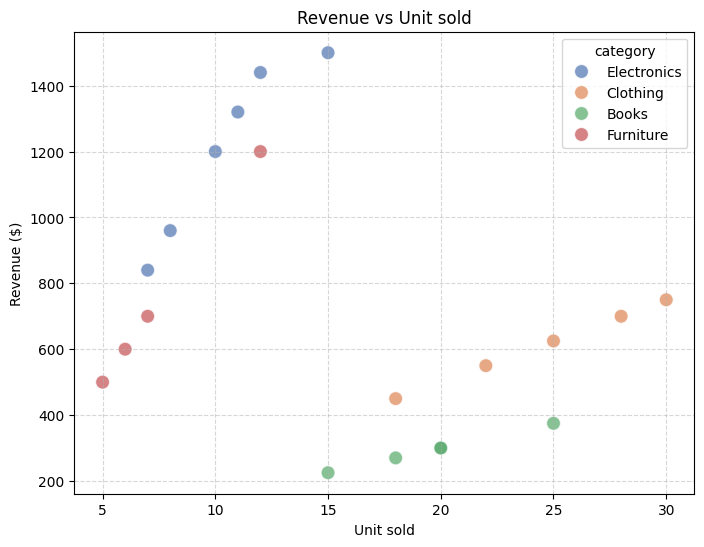

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="units_sold",
    y="revenue_usd",
    hue="category",
    s=100,
    palette="deep",
    alpha=0.7
)

plt.title("Revenue vs Unit sold")
plt.xlabel("Unit sold")
plt.ylabel("Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Чи є відмінності між категоріями на цьому графіку? Як би ти їх охарактеризував(-ла)?
Тепер можно зрозуміти чому відбулося падіння, яке ми бачили на попередньому графіку (без розбивки на категоріі).
Прослідковується класична позитивна кореляція між кількістю та доходом в межах кожної категоріі.